# Pneumonia Detection - Data Preprocessing Pipeline

This notebook implements a comprehensive preprocessing pipeline for the Chest X-Ray dataset (Kermany et al., 2018) for pneumonia detection using deep learning.

**Pipeline Overview:**
1. Dataset loading and analysis
2. Class weight calculation for imbalanced data
3. Stratified train/validation split
4. Data augmentation configuration
5. Data generator creation
6. Pipeline verification
7. Visualization and configuration export

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
from collections import Counter

# TensorFlow/Keras imports
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Scikit-learn imports
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully")

/Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Libraries imported successfully


In [2]:
# Directory configuration
DATA_DIR = Path('../data/chest_xray')
RESULTS_DIR = Path('../results/preprocessing')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify data directory exists
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Results directory: {RESULTS_DIR.resolve()}")

Data directory: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/data/chest_xray
Results directory: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/results/preprocessing


In [3]:
# Preprocessing hyperparameters
IMG_SIZE = 224          # Target size for VGG16/ResNet50 compatibility
BATCH_SIZE = 32         # Batch size for training
VALIDATION_SPLIT = 0.15 # 15% of training data for validation

print("Preprocessing Parameters:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"  Random seed: {RANDOM_SEED}")

Preprocessing Parameters:
  Image size: 224x224 pixels
  Batch size: 32
  Validation split: 15%
  Random seed: 42


## 2. Dataset Loading and Analysis

Analyze the dataset structure, count images per split and class, and identify class imbalance.

In [4]:
def count_images_in_directory(directory):
    """
    Count images in each class subdirectory.
    
    Args:
        directory: Path to the split directory (train/val/test)
    
    Returns:
        Dictionary with class names as keys and image counts as values
    """
    counts = {}
    if not directory.exists():
        print(f"Warning: Directory not found: {directory}")
        return counts
    
    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir() and not class_dir.name.startswith('.'):
            # Count JPEG images
            image_files = list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPEG'))
            counts[class_dir.name] = len(image_files)
    
    return counts


def analyze_dataset(data_dir):
    """
    Comprehensive analysis of the dataset structure.
    
    Args:
        data_dir: Path to the main data directory
    
    Returns:
        Dictionary containing dataset statistics
    """
    splits = ['train', 'val', 'test']
    stats = {}
    
    print("=" * 60)
    print("DATASET ANALYSIS")
    print("=" * 60)
    
    for split in splits:
        split_dir = data_dir / split
        counts = count_images_in_directory(split_dir)
        total = sum(counts.values())
        stats[split] = {'counts': counts, 'total': total}
        
        print(f"\n{split.upper()} SET:")
        print(f"  Total images: {total}")
        for class_name, count in counts.items():
            percentage = (count / total * 100) if total > 0 else 0
            print(f"  - {class_name}: {count} images ({percentage:.1f}%)")
    
    return stats


# Analyze the dataset
dataset_stats = analyze_dataset(DATA_DIR)

DATASET ANALYSIS

TRAIN SET:
  Total images: 5216
  - NORMAL: 1341 images (25.7%)
  - PNEUMONIA: 3875 images (74.3%)

VAL SET:
  Total images: 16
  - NORMAL: 8 images (50.0%)
  - PNEUMONIA: 8 images (50.0%)

TEST SET:
  Total images: 624
  - NORMAL: 234 images (37.5%)
  - PNEUMONIA: 390 images (62.5%)


In [5]:
# Calculate class imbalance ratio for training set
train_counts = dataset_stats['train']['counts']
normal_count = train_counts.get('NORMAL', 0)
pneumonia_count = train_counts.get('PNEUMONIA', 0)

print("\n" + "=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# Calculate imbalance ratio
imbalance_ratio = pneumonia_count / normal_count if normal_count > 0 else 0

print(f"\nTraining Set Class Distribution:")
print(f"  NORMAL:    {normal_count:,} images ({normal_count/(normal_count+pneumonia_count)*100:.1f}%)")
print(f"  PNEUMONIA: {pneumonia_count:,} images ({pneumonia_count/(normal_count+pneumonia_count)*100:.1f}%)")
print(f"\nImbalance Ratio: 1:{imbalance_ratio:.2f} (NORMAL:PNEUMONIA)")
print(f"\nNote: The dataset is imbalanced with ~{pneumonia_count/(normal_count+pneumonia_count)*100:.0f}% pneumonia cases.")
print("      Class weights will be used to address this during training.")


CLASS IMBALANCE ANALYSIS

Training Set Class Distribution:
  NORMAL:    1,341 images (25.7%)
  PNEUMONIA: 3,875 images (74.3%)

Imbalance Ratio: 1:2.89 (NORMAL:PNEUMONIA)

Note: The dataset is imbalanced with ~74% pneumonia cases.
      Class weights will be used to address this during training.


In [6]:
# Highlight the validation set problem
val_total = dataset_stats['val']['total']

print("\n" + "=" * 60)
print("VALIDATION SET ISSUE")
print("=" * 60)

print(f"\nOriginal validation set: {val_total} images")
print(f"This is TOO SMALL for reliable model evaluation!")
print(f"\nSolution: Create a new validation split from the training data.")
print(f"  - Training: 85% of original training data")
print(f"  - Validation: 15% of original training data")
print(f"  - Stratified split to maintain class proportions")


VALIDATION SET ISSUE

Original validation set: 16 images
This is TOO SMALL for reliable model evaluation!

Solution: Create a new validation split from the training data.
  - Training: 85% of original training data
  - Validation: 15% of original training data
  - Stratified split to maintain class proportions


## 3. Class Weight Calculation

Calculate class weights using sklearn's `compute_class_weight` with the 'balanced' strategy to handle class imbalance.

In [7]:
def collect_image_paths_and_labels(data_dir, split='train'):
    """
    Collect all image paths and their corresponding labels.
    
    Args:
        data_dir: Path to the main data directory
        split: Dataset split ('train', 'val', 'test')
    
    Returns:
        Tuple of (image_paths, labels) as numpy arrays
    """
    split_dir = data_dir / split
    image_paths = []
    labels = []
    
    # Class mapping: NORMAL=0, PNEUMONIA=1 (alphabetical order)
    class_mapping = {'NORMAL': 0, 'PNEUMONIA': 1}
    
    for class_name, class_label in class_mapping.items():
        class_dir = split_dir / class_name
        if class_dir.exists():
            for img_path in class_dir.glob('*.jpeg'):
                image_paths.append(str(img_path))
                labels.append(class_label)
            # Also check for .jpg extension
            for img_path in class_dir.glob('*.jpg'):
                image_paths.append(str(img_path))
                labels.append(class_label)
    
    return np.array(image_paths), np.array(labels)


# Collect training data paths and labels
train_paths, train_labels = collect_image_paths_and_labels(DATA_DIR, 'train')

print(f"Collected {len(train_paths)} training images")
print(f"Class distribution: {dict(Counter(train_labels))}")

Collected 5216 training images
Class distribution: {np.int64(0): 1341, np.int64(1): 3875}


In [8]:
# Calculate class weights using sklearn
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Create class weight dictionary
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n" + "=" * 60)
print("CLASS WEIGHTS (Balanced Strategy)")
print("=" * 60)

print(f"\nClass 0 (NORMAL):    {class_weight_dict[0]:.4f}")
print(f"Class 1 (PNEUMONIA): {class_weight_dict[1]:.4f}")

print(f"\nInterpretation:")
print(f"  - NORMAL class gets higher weight ({class_weight_dict[0]:.2f}x) to compensate for fewer samples")
print(f"  - PNEUMONIA class gets lower weight ({class_weight_dict[1]:.2f}x) due to majority representation")
print(f"  - This helps the model pay more attention to the minority class")


CLASS WEIGHTS (Balanced Strategy)

Class 0 (NORMAL):    1.9448
Class 1 (PNEUMONIA): 0.6730

Interpretation:
  - NORMAL class gets higher weight (1.94x) to compensate for fewer samples
  - PNEUMONIA class gets lower weight (0.67x) due to majority representation
  - This helps the model pay more attention to the minority class


In [9]:
# Save class weights to .npy file
weights_save_path = RESULTS_DIR / 'class_weights.npy'
np.save(weights_save_path, class_weights)

print(f"Class weights saved to: {weights_save_path}")

# Verify the saved weights
loaded_weights = np.load(weights_save_path)
print(f"Verification - Loaded weights: {loaded_weights}")

Class weights saved to: ../results/preprocessing/class_weights.npy
Verification - Loaded weights: [1.9448173  0.67303226]


## 4. Stratified Train/Validation Split

Create a proper train/validation split (85%/15%) from the original training data with stratification to maintain class proportions.

In [10]:
# Perform stratified split
train_paths_split, val_paths_split, train_labels_split, val_labels_split = train_test_split(
    train_paths,
    train_labels,
    test_size=VALIDATION_SPLIT,
    stratify=train_labels,
    random_state=RANDOM_SEED
)

print("\n" + "=" * 60)
print("STRATIFIED TRAIN/VALIDATION SPLIT")
print("=" * 60)

print(f"\nOriginal training set: {len(train_paths)} images")
print(f"\nAfter split:")
print(f"  Training set:   {len(train_paths_split)} images ({len(train_paths_split)/len(train_paths)*100:.1f}%)")
print(f"  Validation set: {len(val_paths_split)} images ({len(val_paths_split)/len(train_paths)*100:.1f}%)")

# Verify stratification
train_dist = Counter(train_labels_split)
val_dist = Counter(val_labels_split)

print(f"\nTraining set distribution:")
print(f"  NORMAL:    {train_dist[0]} ({train_dist[0]/len(train_labels_split)*100:.1f}%)")
print(f"  PNEUMONIA: {train_dist[1]} ({train_dist[1]/len(train_labels_split)*100:.1f}%)")

print(f"\nValidation set distribution:")
print(f"  NORMAL:    {val_dist[0]} ({val_dist[0]/len(val_labels_split)*100:.1f}%)")
print(f"  PNEUMONIA: {val_dist[1]} ({val_dist[1]/len(val_labels_split)*100:.1f}%)")

print(f"\nClass proportions are maintained (stratified split successful)")


STRATIFIED TRAIN/VALIDATION SPLIT

Original training set: 5216 images

After split:
  Training set:   4433 images (85.0%)
  Validation set: 783 images (15.0%)

Training set distribution:
  NORMAL:    1140 (25.7%)
  PNEUMONIA: 3293 (74.3%)

Validation set distribution:
  NORMAL:    201 (25.7%)
  PNEUMONIA: 582 (74.3%)

Class proportions are maintained (stratified split successful)


In [11]:
# Create DataFrames for the generators
# This allows us to use flow_from_dataframe which gives us more control

train_df = pd.DataFrame({
    'filepath': train_paths_split,
    'label': ['NORMAL' if l == 0 else 'PNEUMONIA' for l in train_labels_split]
})

val_df = pd.DataFrame({
    'filepath': val_paths_split,
    'label': ['NORMAL' if l == 0 else 'PNEUMONIA' for l in val_labels_split]
})

# Collect test data
test_paths, test_labels = collect_image_paths_and_labels(DATA_DIR, 'test')
test_df = pd.DataFrame({
    'filepath': test_paths,
    'label': ['NORMAL' if l == 0 else 'PNEUMONIA' for l in test_labels]
})

print(f"DataFrames created:")
print(f"  Training:   {len(train_df)} samples")
print(f"  Validation: {len(val_df)} samples")
print(f"  Test:       {len(test_df)} samples")

DataFrames created:
  Training:   4433 samples
  Validation: 783 samples
  Test:       624 samples


## 5. Data Augmentation Configuration

Configure data augmentation for the training set to improve model generalization and help address class imbalance.

**Important:** Vertical flip is NOT used as it would create anatomically incorrect X-ray images.

In [12]:
# Data augmentation parameters
augmentation_params = {
    'rescale': 1./255,           # Normalize to [0, 1]
    'rotation_range': 15,         # Rotation: ±15 degrees
    'width_shift_range': 0.1,     # Width shift: 10%
    'height_shift_range': 0.1,    # Height shift: 10%
    'shear_range': 0.1,           # Shear: 0.1
    'zoom_range': 0.1,            # Zoom: 0.1
    'horizontal_flip': True,      # Horizontal flip: enabled
    'vertical_flip': False,       # Vertical flip: DISABLED (anatomically incorrect)
    'fill_mode': 'nearest'        # Fill mode: nearest
}

print("\n" + "=" * 60)
print("DATA AUGMENTATION CONFIGURATION")
print("=" * 60)

print(f"\nAugmentation Parameters:")
for param, value in augmentation_params.items():
    print(f"  {param}: {value}")

print(f"\nRationale:")
print(f"  - Rotation (±15°): Mimics patient positioning variability")
print(f"  - Shifts (10%): Accounts for X-ray framing differences")
print(f"  - Shear/Zoom: Simulates projection variations")
print(f"  - Horizontal flip: Anatomically valid (bilateral symmetry)")
print(f"  - NO vertical flip: Would create unrealistic images")
print(f"  - Fill mode 'nearest': Preserves edge patterns")


DATA AUGMENTATION CONFIGURATION

Augmentation Parameters:
  rescale: 0.00392156862745098
  rotation_range: 15
  width_shift_range: 0.1
  height_shift_range: 0.1
  shear_range: 0.1
  zoom_range: 0.1
  horizontal_flip: True
  vertical_flip: False
  fill_mode: nearest

Rationale:
  - Rotation (±15°): Mimics patient positioning variability
  - Shifts (10%): Accounts for X-ray framing differences
  - Shear/Zoom: Simulates projection variations
  - Horizontal flip: Anatomically valid (bilateral symmetry)
  - NO vertical flip: Would create unrealistic images
  - Fill mode 'nearest': Preserves edge patterns


In [13]:
# Create ImageDataGenerator for training (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=augmentation_params['rescale'],
    rotation_range=augmentation_params['rotation_range'],
    width_shift_range=augmentation_params['width_shift_range'],
    height_shift_range=augmentation_params['height_shift_range'],
    shear_range=augmentation_params['shear_range'],
    zoom_range=augmentation_params['zoom_range'],
    horizontal_flip=augmentation_params['horizontal_flip'],
    vertical_flip=augmentation_params['vertical_flip'],
    fill_mode=augmentation_params['fill_mode']
)

# Create ImageDataGenerator for validation/test (NO augmentation)
val_test_datagen = ImageDataGenerator(
    rescale=1./255  # Only normalization, no augmentation
)

print("ImageDataGenerators created:")
print("  - Training generator: WITH augmentation")
print("  - Validation/Test generator: WITHOUT augmentation (only rescaling)")

ImageDataGenerators created:
  - Training generator: WITH augmentation
  - Validation/Test generator: WITHOUT augmentation (only rescaling)


## 6. Create Data Generators

Create data generators for training, validation, and test sets using `flow_from_dataframe` to ensure proper data splitting.

In [14]:
# Training generator (with augmentation)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=RANDOM_SEED
)

# Validation generator (no augmentation)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Test generator (no augmentation)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4433 validated image filenames belonging to 2 classes.
Found 783 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


In [15]:
print("\n" + "=" * 60)
print("DATA GENERATORS SUMMARY")
print("=" * 60)

print(f"\nTraining Generator:")
print(f"  Samples: {train_generator.samples}")
print(f"  Batches per epoch: {len(train_generator)}")
print(f"  Class indices: {train_generator.class_indices}")
print(f"  Augmentation: ENABLED")
print(f"  Shuffle: True")

print(f"\nValidation Generator:")
print(f"  Samples: {val_generator.samples}")
print(f"  Batches per epoch: {len(val_generator)}")
print(f"  Class indices: {val_generator.class_indices}")
print(f"  Augmentation: DISABLED")
print(f"  Shuffle: False")

print(f"\nTest Generator:")
print(f"  Samples: {test_generator.samples}")
print(f"  Batches per epoch: {len(test_generator)}")
print(f"  Class indices: {test_generator.class_indices}")
print(f"  Augmentation: DISABLED")
print(f"  Shuffle: False")


DATA GENERATORS SUMMARY

Training Generator:
  Samples: 4433
  Batches per epoch: 139
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
  Augmentation: ENABLED
  Shuffle: True

Validation Generator:
  Samples: 783
  Batches per epoch: 25
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
  Augmentation: DISABLED
  Shuffle: False

Test Generator:
  Samples: 624
  Batches per epoch: 20
  Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
  Augmentation: DISABLED
  Shuffle: False


## 7. Pipeline Verification

Verify that the preprocessing pipeline is working correctly by checking batch shapes, value ranges, and class indices.

In [16]:
# Get a sample batch from each generator
print("\n" + "=" * 60)
print("PIPELINE VERIFICATION")
print("=" * 60)

# Training batch
train_batch_images, train_batch_labels = next(train_generator)
print(f"\nTraining Batch:")
print(f"  Shape: {train_batch_images.shape}")
print(f"  Expected: ({BATCH_SIZE}, {IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"  Labels shape: {train_batch_labels.shape}")
print(f"  Value range: [{train_batch_images.min():.4f}, {train_batch_images.max():.4f}]")
print(f"  Expected range: [0.0000, 1.0000]")

# Validation batch
val_batch_images, val_batch_labels = next(val_generator)
print(f"\nValidation Batch:")
print(f"  Shape: {val_batch_images.shape}")
print(f"  Value range: [{val_batch_images.min():.4f}, {val_batch_images.max():.4f}]")

# Test batch
test_batch_images, test_batch_labels = next(test_generator)
print(f"\nTest Batch:")
print(f"  Shape: {test_batch_images.shape}")
print(f"  Value range: [{test_batch_images.min():.4f}, {test_batch_images.max():.4f}]")


PIPELINE VERIFICATION

Training Batch:
  Shape: (32, 224, 224, 3)
  Expected: (32, 224, 224, 3)
  Labels shape: (32,)
  Value range: [0.0000, 1.0000]
  Expected range: [0.0000, 1.0000]

Validation Batch:
  Shape: (32, 224, 224, 3)
  Value range: [0.0000, 1.0000]

Test Batch:
  Shape: (32, 224, 224, 3)
  Value range: [0.0000, 1.0000]


In [17]:
# Verify value ranges are correct [0, 1]
print("\nValue Range Verification:")

all_valid = True

for name, batch in [('Training', train_batch_images), 
                    ('Validation', val_batch_images), 
                    ('Test', test_batch_images)]:
    min_val, max_val = batch.min(), batch.max()
    is_valid = (min_val >= 0.0) and (max_val <= 1.0)
    status = "PASS" if is_valid else "FAIL"
    print(f"  {name}: [{min_val:.4f}, {max_val:.4f}] - {status}")
    if not is_valid:
        all_valid = False

if all_valid:
    print("\nAll batches have correct value range [0, 1]")
else:
    print("\nWARNING: Some batches have values outside [0, 1] range!")


Value Range Verification:
  Training: [0.0000, 1.0000] - PASS
  Validation: [0.0000, 1.0000] - PASS
  Test: [0.0000, 1.0000] - PASS

All batches have correct value range [0, 1]


In [18]:
# Verify class indices are consistent
print("\nClass Indices Verification:")
print(f"  Training:   {train_generator.class_indices}")
print(f"  Validation: {val_generator.class_indices}")
print(f"  Test:       {test_generator.class_indices}")

# Check consistency
if (train_generator.class_indices == val_generator.class_indices == test_generator.class_indices):
    print("\nClass indices are consistent across all generators")
else:
    print("\nWARNING: Class indices are inconsistent!")


Class Indices Verification:
  Training:   {'NORMAL': 0, 'PNEUMONIA': 1}
  Validation: {'NORMAL': 0, 'PNEUMONIA': 1}
  Test:       {'NORMAL': 0, 'PNEUMONIA': 1}

Class indices are consistent across all generators


In [19]:
# Reset generators to the beginning for actual training
train_generator.reset()
val_generator.reset()
test_generator.reset()

print("Generators reset to the beginning.")

Generators reset to the beginning.


## 8. Visualize Data Augmentation

Create a visualization showing augmented training samples from both classes.


Augmentation visualization saved to: ../results/preprocessing/augmentation_examples.png


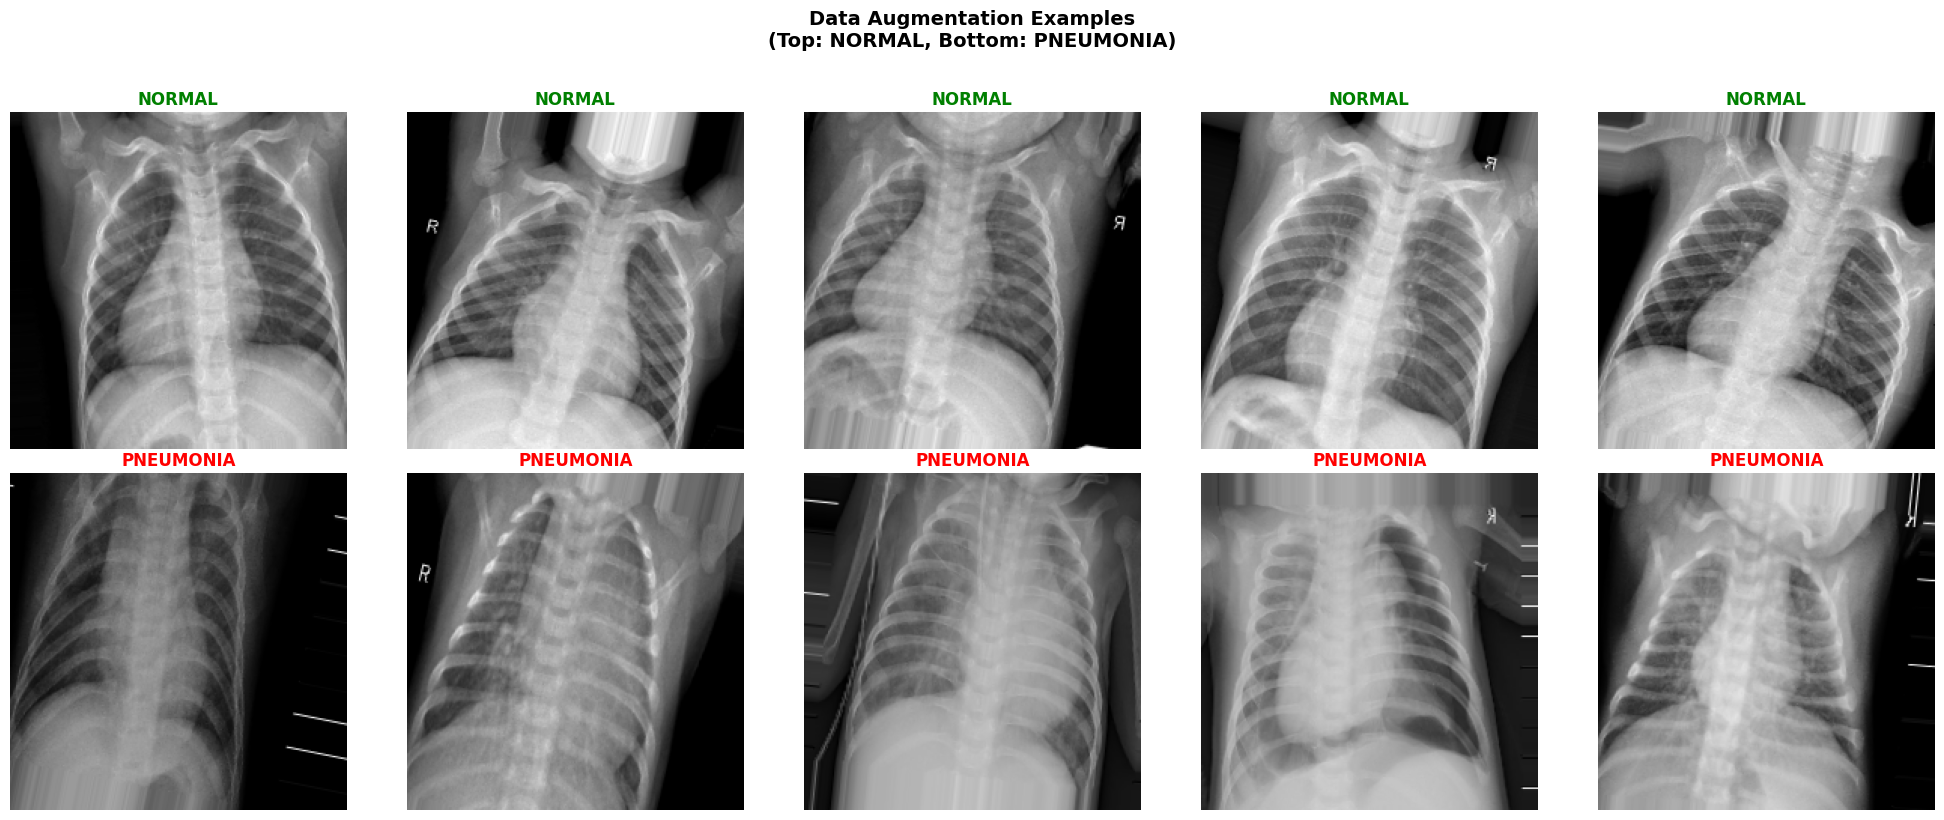

In [20]:
def visualize_augmentation(train_df, datagen, n_samples=10, figsize=(20, 8)):
    """
    Visualize augmented samples from both classes in a 2x5 grid.
    
    Args:
        train_df: Training dataframe with filepaths and labels
        datagen: ImageDataGenerator with augmentation
        n_samples: Number of samples to display (default 10)
        figsize: Figure size
    """
    fig, axes = plt.subplots(2, 5, figsize=figsize)
    axes = axes.flatten()
    
    # Get samples from each class
    normal_samples = train_df[train_df['label'] == 'NORMAL'].sample(n=5, random_state=RANDOM_SEED)
    pneumonia_samples = train_df[train_df['label'] == 'PNEUMONIA'].sample(n=5, random_state=RANDOM_SEED)
    
    # Combine samples (first row: NORMAL, second row: PNEUMONIA)
    samples = pd.concat([normal_samples, pneumonia_samples])
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        # Load and preprocess image
        img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)
        
        # Generate augmented image
        aug_iter = datagen.flow(img_array, batch_size=1, seed=RANDOM_SEED + idx)
        aug_img = next(aug_iter)[0]
        
        # Display
        axes[idx].imshow(aug_img)
        
        # Set title with class label
        label = row['label']
        color = 'green' if label == 'NORMAL' else 'red'
        axes[idx].set_title(label, fontsize=12, fontweight='bold', color=color)
        axes[idx].axis('off')
    
    plt.suptitle('Data Augmentation Examples\n(Top: NORMAL, Bottom: PNEUMONIA)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig


# Create visualization
fig = visualize_augmentation(train_df, train_datagen)

# Save figure
save_path = RESULTS_DIR / 'augmentation_examples.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nAugmentation visualization saved to: {save_path}")

plt.show()

## 9. Save Preprocessing Configuration

Export all preprocessing parameters to a JSON file for reproducibility and documentation.

In [21]:
# Compile preprocessing configuration
preprocessing_config = {
    'dataset': {
        'name': 'Chest X-Ray (Kermany et al., 2018)',
        'original_train_samples': len(train_paths),
        'train_samples': len(train_paths_split),
        'val_samples': len(val_paths_split),
        'test_samples': len(test_paths),
        'classes': ['NORMAL', 'PNEUMONIA'],
        'class_indices': {'NORMAL': 0, 'PNEUMONIA': 1}
    },
    'preprocessing': {
        'target_size': [IMG_SIZE, IMG_SIZE],
        'color_mode': 'rgb',
        'rescale': 1./255,
        'batch_size': BATCH_SIZE,
        'validation_split': VALIDATION_SPLIT,
        'random_seed': RANDOM_SEED
    },
    'augmentation': {
        'rotation_range': augmentation_params['rotation_range'],
        'width_shift_range': augmentation_params['width_shift_range'],
        'height_shift_range': augmentation_params['height_shift_range'],
        'shear_range': augmentation_params['shear_range'],
        'zoom_range': augmentation_params['zoom_range'],
        'horizontal_flip': augmentation_params['horizontal_flip'],
        'vertical_flip': augmentation_params['vertical_flip'],
        'fill_mode': augmentation_params['fill_mode']
    },
    'class_weights': {
        'NORMAL': float(class_weight_dict[0]),
        'PNEUMONIA': float(class_weight_dict[1])
    },
    'class_distribution': {
        'train': {
            'NORMAL': int(train_dist[0]),
            'PNEUMONIA': int(train_dist[1])
        },
        'val': {
            'NORMAL': int(val_dist[0]),
            'PNEUMONIA': int(val_dist[1])
        }
    }
}

# Save configuration to JSON
config_save_path = RESULTS_DIR / 'preprocessing_config.json'
with open(config_save_path, 'w') as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"Preprocessing configuration saved to: {config_save_path}")

Preprocessing configuration saved to: ../results/preprocessing/preprocessing_config.json


In [22]:
# Display the configuration
print("\n" + "=" * 60)
print("PREPROCESSING CONFIGURATION")
print("=" * 60)
print(json.dumps(preprocessing_config, indent=2))


PREPROCESSING CONFIGURATION
{
  "dataset": {
    "name": "Chest X-Ray (Kermany et al., 2018)",
    "original_train_samples": 5216,
    "train_samples": 4433,
    "val_samples": 783,
    "test_samples": 624,
    "classes": [
      "NORMAL",
      "PNEUMONIA"
    ],
    "class_indices": {
      "NORMAL": 0,
      "PNEUMONIA": 1
    }
  },
  "preprocessing": {
    "target_size": [
      224,
      224
    ],
    "color_mode": "rgb",
    "rescale": 0.00392156862745098,
    "batch_size": 32,
    "validation_split": 0.15,
    "random_seed": 42
  },
  "augmentation": {
    "rotation_range": 15,
    "width_shift_range": 0.1,
    "height_shift_range": 0.1,
    "shear_range": 0.1,
    "zoom_range": 0.1,
    "horizontal_flip": true,
    "vertical_flip": false,
    "fill_mode": "nearest"
  },
  "class_weights": {
    "NORMAL": 1.9448173005219984,
    "PNEUMONIA": 0.6730322580645162
  },
  "class_distribution": {
    "train": {
      "NORMAL": 1140,
      "PNEUMONIA": 3293
    },
    "val": {
    

## 10. Summary

Final summary of the preprocessing pipeline and outputs.

In [23]:
print("\n" + "=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)

print(f"\nDataset Statistics:")
print(f"  Original training set:  {len(train_paths):,} images")
print(f"  New training set:       {len(train_paths_split):,} images (85%)")
print(f"  New validation set:     {len(val_paths_split):,} images (15%)")
print(f"  Test set:               {len(test_paths):,} images")

print(f"\nClass Imbalance:")
print(f"  Ratio: 1:{imbalance_ratio:.2f} (NORMAL:PNEUMONIA)")
print(f"  Class weights applied: NORMAL={class_weight_dict[0]:.4f}, PNEUMONIA={class_weight_dict[1]:.4f}")

print(f"\nImage Preprocessing:")
print(f"  Target size: {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"  Normalization: [0, 1] range")
print(f"  Color mode: RGB (3 channels)")
print(f"  Batch size: {BATCH_SIZE}")

print(f"\nData Augmentation (Training only):")
print(f"  Rotation: ±{augmentation_params['rotation_range']}°")
print(f"  Width/Height shift: {augmentation_params['width_shift_range']*100:.0f}%")
print(f"  Shear: {augmentation_params['shear_range']}")
print(f"  Zoom: {augmentation_params['zoom_range']}")
print(f"  Horizontal flip: {augmentation_params['horizontal_flip']}")
print(f"  Vertical flip: {augmentation_params['vertical_flip']} (disabled - anatomically incorrect)")

print(f"\nOutput Files:")
print(f"  Class weights:    {RESULTS_DIR / 'class_weights.npy'}")
print(f"  Augmentation viz: {RESULTS_DIR / 'augmentation_examples.png'}")
print(f"  Config file:      {RESULTS_DIR / 'preprocessing_config.json'}")

print(f"\nData Generators Ready:")
print(f"  - train_generator ({train_generator.samples} samples, augmented, shuffled)")
print(f"  - val_generator ({val_generator.samples} samples, no augmentation, not shuffled)")
print(f"  - test_generator ({test_generator.samples} samples, no augmentation, not shuffled)")

print(f"\nPreprocessing pipeline complete!")


PREPROCESSING PIPELINE SUMMARY

Dataset Statistics:
  Original training set:  5,216 images
  New training set:       4,433 images (85%)
  New validation set:     783 images (15%)
  Test set:               624 images

Class Imbalance:
  Ratio: 1:2.89 (NORMAL:PNEUMONIA)
  Class weights applied: NORMAL=1.9448, PNEUMONIA=0.6730

Image Preprocessing:
  Target size: 224x224 pixels
  Normalization: [0, 1] range
  Color mode: RGB (3 channels)
  Batch size: 32

Data Augmentation (Training only):
  Rotation: ±15°
  Width/Height shift: 10%
  Shear: 0.1
  Zoom: 0.1
  Horizontal flip: True
  Vertical flip: False (disabled - anatomically incorrect)

Output Files:
  Class weights:    ../results/preprocessing/class_weights.npy
  Augmentation viz: ../results/preprocessing/augmentation_examples.png
  Config file:      ../results/preprocessing/preprocessing_config.json

Data Generators Ready:
  - train_generator (4433 samples, augmented, shuffled)
  - val_generator (783 samples, no augmentation, not shu

In [24]:
# Summary of variables available for model training
print("\n" + "=" * 60)
print("VARIABLES AVAILABLE FOR MODEL TRAINING")
print("=" * 60)

print(f"\nData Generators:")
print(f"  train_generator  - Training data with augmentation")
print(f"  val_generator    - Validation data (no augmentation)")
print(f"  test_generator   - Test data (no augmentation)")

print(f"\nClass Weights:")
print(f"  class_weight_dict = {class_weight_dict}")

print(f"\nConfiguration:")
print(f"  IMG_SIZE = {IMG_SIZE}")
print(f"  BATCH_SIZE = {BATCH_SIZE}")
print(f"  RANDOM_SEED = {RANDOM_SEED}")

print(f"\nUsage in model.fit():")
print(f"  model.fit(")
print(f"      train_generator,")
print(f"      validation_data=val_generator,")
print(f"      epochs=...,")
print(f"      class_weight=class_weight_dict")
print(f"  )")


VARIABLES AVAILABLE FOR MODEL TRAINING

Data Generators:
  train_generator  - Training data with augmentation
  val_generator    - Validation data (no augmentation)
  test_generator   - Test data (no augmentation)

Class Weights:
  class_weight_dict = {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

Configuration:
  IMG_SIZE = 224
  BATCH_SIZE = 32
  RANDOM_SEED = 42

Usage in model.fit():
  model.fit(
      train_generator,
      validation_data=val_generator,
      epochs=...,
      class_weight=class_weight_dict
  )
